In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

from datetime import datetime

plt.rcParams['font.sans-serif'] = ['SimHei'] # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False # 用来正常显示负号 #有中文出现的情况，需要u'内容'

In [2]:
caregiver_data = pd.read_csv('护工信息（扩展后）.csv', encoding='GBK')
caregiver_cnt = caregiver_data.shape[0]
caregiver_data

,护工ID,护工姓名,性别,生日,从业时间,服务商ID,所属服务商,评分（满分5分）,常驻医院,创建时间,...,身高,体重,民族,宗教信仰,普通话程度,方言,方言程度,擅长科室,擅长病人,学历
0,478,史小平,女,1970/11/10,2010/12/31,1,宁波安欣陪护服务有限公司,4.6,宁波大学附属第一医院（外滩院区）,2023/5/14 23:22,...,159.0,58.0,汉族,无宗教信仰,能听懂能交流,宁波话,能听懂,消化科,消化科病人,初中
1,1494,张清荣,女,1973/7/13,NaN,21,江苏美世界物业管理有限公司,4.9,宁波大学附属第一医院（方桥院区）,2023/9/1 16:21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1495,余世梅,女,1970/9/4,NaN,21,江苏美世界物业管理有限公司,4.5,宁波大学附属第一医院（方桥院区）,2023/9/1 16:21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1496,王正凡,男,1965/5/18,NaN,21,江苏美世界物业管理有限公司,5.0,宁波大学附属第一医院（方桥院区）,2023/9/1 16:21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1497,周新云,女,1966/11/13,NaN,21,江苏美世界物业管理有限公司,4.9,宁波大学附属第一医院（方桥院区）,2023/9/1 16:21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
813,6310,潘升银,男,1974/2/19,NaN,45,上海智服人力资源有限公司,5.0,宁波大学附属第一医院（方桥院区）,2024/9/25 10:31,...,NaN,NaN,汉族,无宗教信仰,能听懂能交流,宁波话,能听懂能交流,不限,不限,NaN
814,6311,黄秋香,女,1972/6/28,NaN,45,上海智服人力资源有限公司,4.7,宁波大学附属第一医院（方桥院区）,2024/9/25 10:40,...,NaN,NaN,汉族,无宗教信仰,能听懂能交流,宁波话,能听懂能交流,不限,不限,NaN
815,6312,丁碧芳,女,NaN,NaN,21,江苏美世界物业管理有限公司,4.5,宁波大学附属第一医院（月湖院区）,2024/9/25 10:50,...,NaN,NaN,汉族,无宗教信仰,能听懂能交流,宁波话,能听懂能交流,不限,不限,NaN
816,6332,贺昔妹,女,NaN,NaN,45,上海智服人力资源有限公司,NaN,宁波大学附属第一医院（方桥院区）,2024/9/27 8:34,...,NaN,NaN,汉族,无宗教信仰,能听懂能交流,宁波话,能听懂能交流,不限,不限,NaN


In [3]:
# 以2024年9月30号为标准
def age_calculate(year, month, day):
    age = 2024 - year
    if 9 < month or (9 == month and 30 < day):
        age -= 1

    return age

age_list = []
for i in range(caregiver_cnt):
    if type(caregiver_data.iloc[i]['生日']) != str:
        age_list.append(np.nan)
    else:
        age_info = caregiver_data.iloc[i]['生日'].split('/')
        [year, month, day] = [int(val) for val in age_info]
        age_list.append(age_calculate(year, month, day))
caregiver_data['年龄'] = age_list
caregiver_data

,护工ID,护工姓名,性别,生日,从业时间,服务商ID,所属服务商,评分（满分5分）,常驻医院,创建时间,...,体重,民族,宗教信仰,普通话程度,方言,方言程度,擅长科室,擅长病人,学历,年龄
0,478,史小平,女,1970/11/10,2010/12/31,1,宁波安欣陪护服务有限公司,4.6,宁波大学附属第一医院（外滩院区）,2023/5/14 23:22,...,58.0,汉族,无宗教信仰,能听懂能交流,宁波话,能听懂,消化科,消化科病人,初中,53.0
1,1494,张清荣,女,1973/7/13,NaN,21,江苏美世界物业管理有限公司,4.9,宁波大学附属第一医院（方桥院区）,2023/9/1 16:21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51.0
2,1495,余世梅,女,1970/9/4,NaN,21,江苏美世界物业管理有限公司,4.5,宁波大学附属第一医院（方桥院区）,2023/9/1 16:21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,54.0
3,1496,王正凡,男,1965/5/18,NaN,21,江苏美世界物业管理有限公司,5.0,宁波大学附属第一医院（方桥院区）,2023/9/1 16:21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,59.0
4,1497,周新云,女,1966/11/13,NaN,21,江苏美世界物业管理有限公司,4.9,宁波大学附属第一医院（方桥院区）,2023/9/1 16:21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,57.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
813,6310,潘升银,男,1974/2/19,NaN,45,上海智服人力资源有限公司,5.0,宁波大学附属第一医院（方桥院区）,2024/9/25 10:31,...,NaN,汉族,无宗教信仰,能听懂能交流,宁波话,能听懂能交流,不限,不限,NaN,50.0
814,6311,黄秋香,女,1972/6/28,NaN,45,上海智服人力资源有限公司,4.7,宁波大学附属第一医院（方桥院区）,2024/9/25 10:40,...,NaN,汉族,无宗教信仰,能听懂能交流,宁波话,能听懂能交流,不限,不限,NaN,52.0
815,6312,丁碧芳,女,NaN,NaN,21,江苏美世界物业管理有限公司,4.5,宁波大学附属第一医院（月湖院区）,2024/9/25 10:50,...,NaN,汉族,无宗教信仰,能听懂能交流,宁波话,能听懂能交流,不限,不限,NaN,NaN
816,6332,贺昔妹,女,NaN,NaN,45,上海智服人力资源有限公司,NaN,宁波大学附属第一医院（方桥院区）,2024/9/27 8:34,...,NaN,汉族,无宗教信仰,能听懂能交流,宁波话,能听懂能交流,不限,不限,NaN,NaN


In [4]:
# 检测异常值
caregiver_data['年龄'].unique()

array([53., 51., 54., 59., 57., 56., 36., 64., 60., 52., 48., 62., 55.,
       50., 58., 49., 67., 45., 47., 61., 66., 44., 63., 71., 43., 46.,
       nan,  0., 65., 38., 41., 40., 42., 35., 39., 37., 33., 34., 31.])

In [5]:
# 删除异常值0
caregiver_data = caregiver_data.drop(caregiver_data[caregiver_data['年龄'] == 0].index)
caregiver_cnt = caregiver_data.shape[0]

# 均值填充
age_mean = round(caregiver_data['年龄'].mean())
caregiver_data['年龄'] = caregiver_data['年龄'].fillna(age_mean)

caregiver_data['年龄'] = caregiver_data['年龄'].astype(int)
caregiver_data

,护工ID,护工姓名,性别,生日,从业时间,服务商ID,所属服务商,评分（满分5分）,常驻医院,创建时间,...,体重,民族,宗教信仰,普通话程度,方言,方言程度,擅长科室,擅长病人,学历,年龄
0,478,史小平,女,1970/11/10,2010/12/31,1,宁波安欣陪护服务有限公司,4.6,宁波大学附属第一医院（外滩院区）,2023/5/14 23:22,...,58.0,汉族,无宗教信仰,能听懂能交流,宁波话,能听懂,消化科,消化科病人,初中,53
1,1494,张清荣,女,1973/7/13,NaN,21,江苏美世界物业管理有限公司,4.9,宁波大学附属第一医院（方桥院区）,2023/9/1 16:21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51
2,1495,余世梅,女,1970/9/4,NaN,21,江苏美世界物业管理有限公司,4.5,宁波大学附属第一医院（方桥院区）,2023/9/1 16:21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,54
3,1496,王正凡,男,1965/5/18,NaN,21,江苏美世界物业管理有限公司,5.0,宁波大学附属第一医院（方桥院区）,2023/9/1 16:21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,59
4,1497,周新云,女,1966/11/13,NaN,21,江苏美世界物业管理有限公司,4.9,宁波大学附属第一医院（方桥院区）,2023/9/1 16:21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,57
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
813,6310,潘升银,男,1974/2/19,NaN,45,上海智服人力资源有限公司,5.0,宁波大学附属第一医院（方桥院区）,2024/9/25 10:31,...,NaN,汉族,无宗教信仰,能听懂能交流,宁波话,能听懂能交流,不限,不限,NaN,50
814,6311,黄秋香,女,1972/6/28,NaN,45,上海智服人力资源有限公司,4.7,宁波大学附属第一医院（方桥院区）,2024/9/25 10:40,...,NaN,汉族,无宗教信仰,能听懂能交流,宁波话,能听懂能交流,不限,不限,NaN,52
815,6312,丁碧芳,女,NaN,NaN,21,江苏美世界物业管理有限公司,4.5,宁波大学附属第一医院（月湖院区）,2024/9/25 10:50,...,NaN,汉族,无宗教信仰,能听懂能交流,宁波话,能听懂能交流,不限,不限,NaN,52
816,6332,贺昔妹,女,NaN,NaN,45,上海智服人力资源有限公司,NaN,宁波大学附属第一医院（方桥院区）,2024/9/27 8:34,...,NaN,汉族,无宗教信仰,能听懂能交流,宁波话,能听懂能交流,不限,不限,NaN,52


In [6]:
# 以2024年9月30号为标准
def workTime_calculate(year, month, day):
    return (datetime(2024, 9, 30) - datetime(year, month, day)).days

workTime_list = []
for i in range(caregiver_cnt):
    workTime_info = caregiver_data.iloc[i]['创建时间'].split(' ')[0].split('/')
    [year, month, day] = [int(val) for val in workTime_info]
    workTime_list.append(workTime_calculate(year, month, day))
caregiver_data['工作时长'] = workTime_list
caregiver_data

,护工ID,护工姓名,性别,生日,从业时间,服务商ID,所属服务商,评分（满分5分）,常驻医院,创建时间,...,民族,宗教信仰,普通话程度,方言,方言程度,擅长科室,擅长病人,学历,年龄,工作时长
0,478,史小平,女,1970/11/10,2010/12/31,1,宁波安欣陪护服务有限公司,4.6,宁波大学附属第一医院（外滩院区）,2023/5/14 23:22,...,汉族,无宗教信仰,能听懂能交流,宁波话,能听懂,消化科,消化科病人,初中,53,505
1,1494,张清荣,女,1973/7/13,NaN,21,江苏美世界物业管理有限公司,4.9,宁波大学附属第一医院（方桥院区）,2023/9/1 16:21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51,395
2,1495,余世梅,女,1970/9/4,NaN,21,江苏美世界物业管理有限公司,4.5,宁波大学附属第一医院（方桥院区）,2023/9/1 16:21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,54,395
3,1496,王正凡,男,1965/5/18,NaN,21,江苏美世界物业管理有限公司,5.0,宁波大学附属第一医院（方桥院区）,2023/9/1 16:21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,59,395
4,1497,周新云,女,1966/11/13,NaN,21,江苏美世界物业管理有限公司,4.9,宁波大学附属第一医院（方桥院区）,2023/9/1 16:21,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,57,395
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
813,6310,潘升银,男,1974/2/19,NaN,45,上海智服人力资源有限公司,5.0,宁波大学附属第一医院（方桥院区）,2024/9/25 10:31,...,汉族,无宗教信仰,能听懂能交流,宁波话,能听懂能交流,不限,不限,NaN,50,5
814,6311,黄秋香,女,1972/6/28,NaN,45,上海智服人力资源有限公司,4.7,宁波大学附属第一医院（方桥院区）,2024/9/25 10:40,...,汉族,无宗教信仰,能听懂能交流,宁波话,能听懂能交流,不限,不限,NaN,52,5
815,6312,丁碧芳,女,NaN,NaN,21,江苏美世界物业管理有限公司,4.5,宁波大学附属第一医院（月湖院区）,2024/9/25 10:50,...,汉族,无宗教信仰,能听懂能交流,宁波话,能听懂能交流,不限,不限,NaN,52,5
816,6332,贺昔妹,女,NaN,NaN,45,上海智服人力资源有限公司,NaN,宁波大学附属第一医院（方桥院区）,2024/9/27 8:34,...,汉族,无宗教信仰,能听懂能交流,宁波话,能听懂能交流,不限,不限,NaN,52,3


In [7]:
score_mean = round(caregiver_data['评分（满分5分）'].mean(), 1)

# 均值填充
caregiver_data['评分（满分5分）'] = caregiver_data['评分（满分5分）'].fillna(score_mean)

In [8]:
# 统计离散型特征分布
def count(df, col):
    res = []
    values = df[col].unique()
    for i, val in enumerate(values):
        if type(val) == str:
            res.append(df[df[col] == val].shape[0])
        else:
            values[i] = '未知'
            res.append(df[col].isnull().sum())
    
    return [list(values), res]

In [9]:
caregiver_data.columns

Index(['护工ID', '护工姓名', '性别', '生日', '从业时间', '服务商ID', '所属服务商', '评分（满分5分）',
       '常驻医院', '创建时间', '省', '市', '区', '身高', '体重', '民族', '宗教信仰', '普通话程度', '方言',
       '方言程度', '擅长科室', '擅长病人', '学历', '年龄', '工作时长'],
      dtype='object')

[['女', '男'], [744, 73]]
[['宁波安欣陪护服务有限公司', '江苏美世界物业管理有限公司', '小柏家护', '上海智服人力资源有限公司'], [371, 387, 1, 58]]
[['宁波大学附属第一医院（外滩院区）', '宁波大学附属第一医院（方桥院区）', '宁波大学附属第一医院（月湖院区）'], [372, 174, 271]]
[['河南省', '未知', '浙江省', '安徽省', '江苏省', '贵州省', '四川省', '重庆市', '江西省', '湖北省'], [24, 781, 2, 1, 3, 1, 2, 1, 1, 1]]
[['汉族', '未知'], [317, 500]]
[['无宗教信仰', '未知', '天主教'], [316, 500, 1]]
[['能听懂能交流', '未知'], [317, 500]]
[['宁波话', '未知', '其他'], [315, 500, 2]]
[['能听懂', '未知', '能听懂能交流', '不熟练'], [1, 500, 312, 4]]
[['消化科', '未知', '不限'], [1, 500, 316]]
[['消化科病人', '未知', '不限'], [1, 500, 316]]
[['初中', '未知'], [18, 799]]


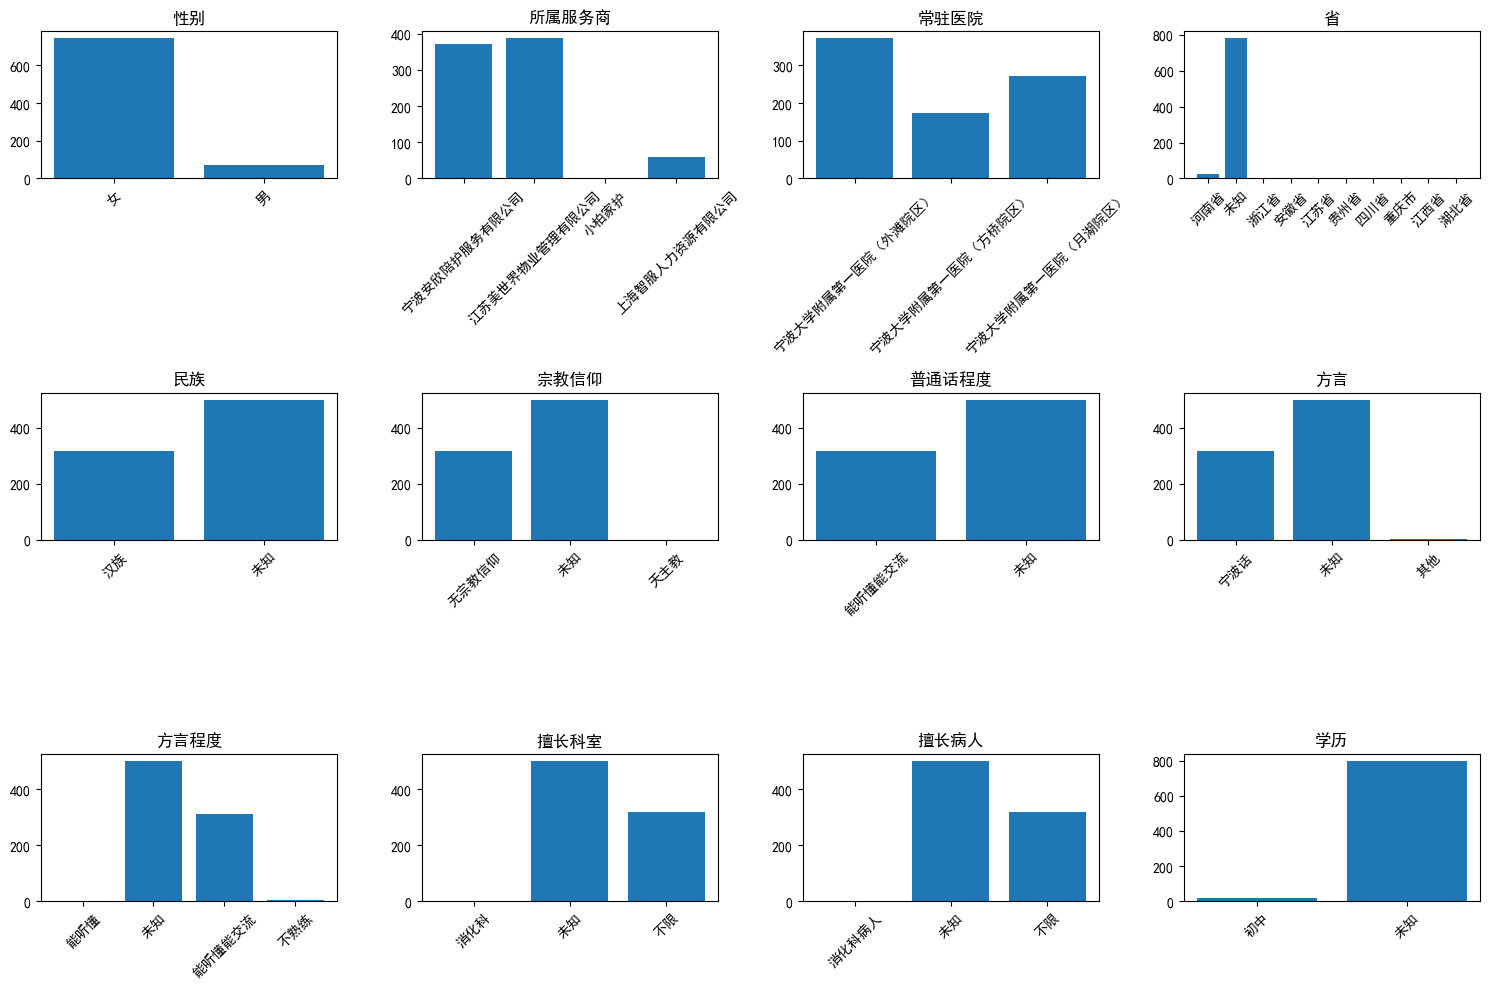

In [10]:
fig, axs = plt.subplots(3, 4, figsize=(15, 10))

token_columns = ['性别', '所属服务商', '常驻医院', '省', '民族', '宗教信仰', '普通话程度', '方言', '方言程度', '擅长科室', '擅长病人', '学历']
for i, col in enumerate(token_columns):
    x_data, y_data = count(caregiver_data, col)
    print([x_data, y_data])
    r = i // 4
    c = i % 4
    axs[r, c].bar(x_data, y_data)
    axs[r, c].set_title(f'{col}')
    axs[r, c].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

<Axes: ylabel='Density'>

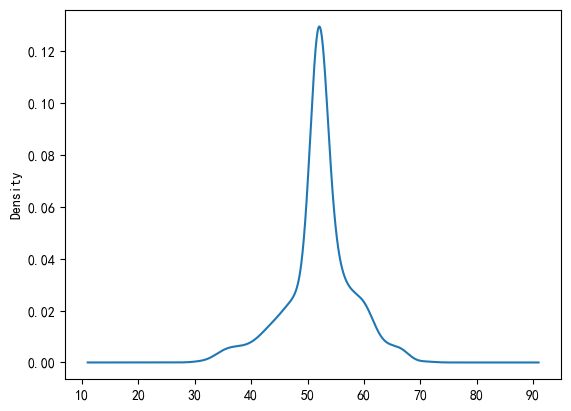

In [11]:
caregiver_data['年龄'].plot(kind='kde', label='密度图')

<Axes: ylabel='Density'>

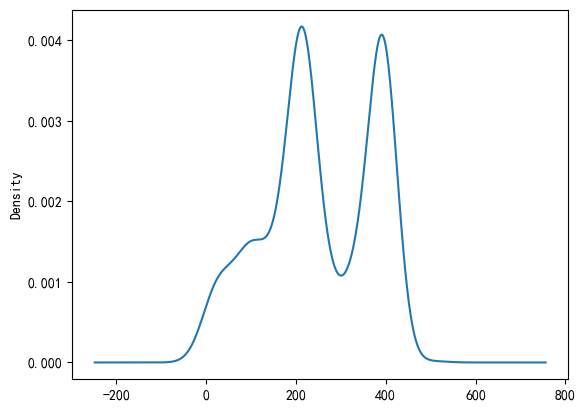

In [12]:
caregiver_data['工作时长'].plot(kind='kde', label='密度图')

In [13]:
order_data = pd.read_csv('订单信息.csv', encoding='GBK').dropna(subset=['床位号'])
order_data

,订单号,费用,已支付费用,已退款费用,服务天数,医院ID,医院名称,病区ID,病区名称,床位号,...,服务商ID,服务商名称,患者年龄,患者性别,护工ID,护工姓名,订单类型,接单时间,关闭时间,创建时间
7,3.190000e+16,720,0,0,3,2,宁波大学附属第一医院（外滩院区）,49,绣山医学楼 12楼,46,...,1,宁波安欣陪护服务有限公司,0,男,466,杨向?,一对一,NaN,2023/12/12 17:52,2023/8/16 10:54
8,3.670000e+16,720,0,0,3,2,宁波大学附属第一医院（外滩院区）,51,绣山医学楼 14楼 RICU,5,...,1,宁波安欣陪护服务有限公司,0,男,484,李卫红,一对一,NaN,2023/12/12 17:52,2023/8/29 19:18
9,3.770000e+16,660,0,0,3,3,宁波大学附属第一医院（月湖院区）,285,2号楼 21楼,31,...,15,小柏家护,73,男,56,余良仙,一对一,NaN,2023/12/12 17:52,2023/9/1 15:04
10,3.800000e+16,960,0,0,4,3,宁波大学附属第一医院（月湖院区）,278,2号楼 14楼,29,...,21,江苏美世界物业管理有限公司,0,男,1662,赵桂琴,一对一,NaN,2023/12/12 17:52,2023/9/2 9:45
11,3.800000e+16,720,0,0,3,3,宁波大学附属第一医院（月湖院区）,277,2号楼 13楼,23,...,21,江苏美世界物业管理有限公司,0,男,1673,杨莉,一对一,NaN,2023/12/12 17:52,2023/9/2 10:03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6833,1.790000e+17,600,600,0,2,2,宁波大学附属第一医院（外滩院区）,44,1号楼 7楼,21,...,1,宁波安欣陪护服务有限公司,36,男,2123,牛小玲,一对一,2024/9/26 16:08,NaN,2024/9/26 16:07
6834,1.790000e+17,500,500,0,2,16,宁波大学附属第一医院（方桥院区）,371,6号楼 6楼,1,...,45,上海智服人力资源有限公司,62,男,6332,贺昔妹,一对一,2024/9/26 16:48,NaN,2024/9/26 16:40
6835,1.790000e+17,1250,0,0,5,3,宁波大学附属第一医院（月湖院区）,306,5号楼 9楼,32,...,21,江苏美世界物业管理有限公司,67,男,1599,黄玉枝,一对一,2024/9/26 19:52,NaN,2024/9/26 19:39
6836,1.800000e+17,500,500,0,2,2,宁波大学附属第一医院（外滩院区）,33,1号楼 12楼,17,...,15,小柏家护,33,女,1905,马献芬,一对一,2024/9/27 10:36,NaN,2024/9/27 10:35


In [14]:
orderCnt_list = []
activeDegree_list = []
for i in range(caregiver_cnt):
    ID = caregiver_data.iloc[i]['护工ID']
    df = order_data[order_data['护工ID'] == ID]
    
    orderCnt = df.shape[0]
    activeDays = df['服务天数'].sum()
    activeDegree = round(activeDays / caregiver_data.iloc[i]['工作时长'], 2)
    
    orderCnt_list.append(df.shape[0])
    activeDegree_list.append(activeDegree)

caregiver_data['订单数'] = orderCnt_list
caregiver_data['活跃度'] = activeDegree_list
caregiver_data

,护工ID,护工姓名,性别,生日,从业时间,服务商ID,所属服务商,评分（满分5分）,常驻医院,创建时间,...,普通话程度,方言,方言程度,擅长科室,擅长病人,学历,年龄,工作时长,订单数,活跃度
0,478,史小平,女,1970/11/10,2010/12/31,1,宁波安欣陪护服务有限公司,4.6,宁波大学附属第一医院（外滩院区）,2023/5/14 23:22,...,能听懂能交流,宁波话,能听懂,消化科,消化科病人,初中,53,505,23,0.16
1,1494,张清荣,女,1973/7/13,NaN,21,江苏美世界物业管理有限公司,4.9,宁波大学附属第一医院（方桥院区）,2023/9/1 16:21,...,NaN,NaN,NaN,NaN,NaN,NaN,51,395,7,0.06
2,1495,余世梅,女,1970/9/4,NaN,21,江苏美世界物业管理有限公司,4.5,宁波大学附属第一医院（方桥院区）,2023/9/1 16:21,...,NaN,NaN,NaN,NaN,NaN,NaN,54,395,5,0.07
3,1496,王正凡,男,1965/5/18,NaN,21,江苏美世界物业管理有限公司,5.0,宁波大学附属第一医院（方桥院区）,2023/9/1 16:21,...,NaN,NaN,NaN,NaN,NaN,NaN,59,395,2,0.01
4,1497,周新云,女,1966/11/13,NaN,21,江苏美世界物业管理有限公司,4.9,宁波大学附属第一医院（方桥院区）,2023/9/1 16:21,...,NaN,NaN,NaN,NaN,NaN,NaN,57,395,6,0.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
813,6310,潘升银,男,1974/2/19,NaN,45,上海智服人力资源有限公司,5.0,宁波大学附属第一医院（方桥院区）,2024/9/25 10:31,...,能听懂能交流,宁波话,能听懂能交流,不限,不限,NaN,50,5,0,0.00
814,6311,黄秋香,女,1972/6/28,NaN,45,上海智服人力资源有限公司,4.7,宁波大学附属第一医院（方桥院区）,2024/9/25 10:40,...,能听懂能交流,宁波话,能听懂能交流,不限,不限,NaN,52,5,0,0.00
815,6312,丁碧芳,女,NaN,NaN,21,江苏美世界物业管理有限公司,4.5,宁波大学附属第一医院（月湖院区）,2024/9/25 10:50,...,能听懂能交流,宁波话,能听懂能交流,不限,不限,NaN,52,5,0,0.00
816,6332,贺昔妹,女,NaN,NaN,45,上海智服人力资源有限公司,4.7,宁波大学附属第一医院（方桥院区）,2024/9/27 8:34,...,能听懂能交流,宁波话,能听懂能交流,不限,不限,NaN,52,3,1,0.67


<Axes: ylabel='Density'>

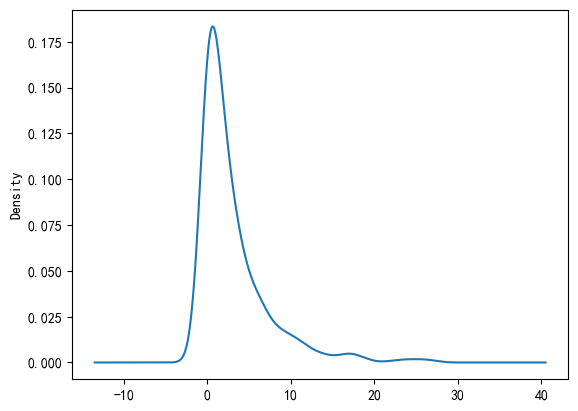

In [15]:
caregiver_data['订单数'].plot(kind='kde', label='密度图')

In [16]:
caregiver_data['订单数'].sum()

2485

In [17]:
caregiver_data.to_csv('护工信息.csv', index=False)